# Sweep Analysis — Parameter Importance & Top-N Hyperparameter Distributions

Analyzes the **top N runs** (by goal metric) of a single wandb sweep, entirely
from local files:

- **No wandb API calls.** There is no network access to the wandb cloud API in
  this environment, so this notebook reads only local caches.
- **Sweep scoping.** `runs/` on disk contains completed runs from *every* sweep
  that has ever used `src/sweep_train.py`, not just the current one. To isolate
  one sweep, this notebook globs `wandb/sweep-{SWEEP_ID}/config-*.yaml` — one
  file per run that belongs to that sweep — and only loads
  `runs/<run_id>/final_meta.json` for those run_ids.
- **Two analyses**, mirroring wandb's own dashboard panels but restricted to the
  top-N subset instead of all runs:
  1. A `RandomForestRegressor`-based parameter-importance bar chart.
  2. A grid of per-hyperparameter scatter plots (value vs. goal metric), with
     axis scale/limits taken from `sweeps/sweep.yaml`'s search space.


The notebook has two parallel analyses using the same two figure types:
1. Runs ranked by their **final-epoch** goal metric (from `final_meta.json`).
2. Runs ranked by the **best-ever** goal metric they reached at *any* epoch during training (parsed from each run's local wandb history log, since training here has no early stopping and often keeps going past the peak).

In [1]:
import glob
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from wandb.sdk.internal.datastore import DataStore
from wandb.proto import wandb_internal_pb2 as pb

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "sweeps" else Path.cwd()

# --- editable analysis parameters ---
SWEEP_ID = "j6z4dh1u"
TOP_N = 400
RNG_SEED = 42
N_GRID_COLS = 3

SWEEP_YAML_PATH = REPO_ROOT / "sweeps" / "sweep.yaml"
WANDB_DIR = REPO_ROOT / "wandb"
RUNS_DIR = REPO_ROOT / "runs"

## Parse `sweep.yaml`

In [2]:
with open(SWEEP_YAML_PATH) as f:
    sweep_cfg = yaml.safe_load(f)

metric_name = sweep_cfg["metric"]["name"]      # e.g. "val/goal_metric" (display only)
metric_col = metric_name.replace("/", "_")     # e.g. "val_goal_metric" (actual final_meta.json key)
goal = sweep_cfg["metric"]["goal"]             # "maximize" or "minimize"

LOG_DISTRIBUTIONS = {"log_uniform_values", "q_log_uniform_values"}

# param_specs preserves the yaml's declared order (PyYAML + dict ordering) --
# intentionally not sorted, so related hyperparameters (trunk / cls head /
# reg head / optimizer) stay grouped in the plots below.
param_specs = {}
for name, spec in sweep_cfg["parameters"].items():
    if "value" in spec:
        continue  # fixed constant (e.g. split_dir, eta_min) -- not swept, skip
    if "values" in spec:
        vals = spec["values"]
        # Categorical params come in two flavors: numeric (n_layers, use_ecfp,
        # ...) plot at their real integer values; string categoricals (pprop_norm
        # = none/zscore/minmax) have no numeric axis, so encode them by their
        # position in the yaml's declared order. `cat_to_pos` is shared by the
        # scatter grid and the RandomForest encoding so positions stay aligned.
        numeric = all(isinstance(v, (int, float)) and not isinstance(v, bool) for v in vals)
        if numeric:
            param_specs[name] = dict(
                kind="categorical",
                numeric=True,
                log=False,
                values=vals,
                xlim=(min(vals) - 0.5, max(vals) + 0.5),
                xticks=vals,
                cat_to_pos=None,
            )
        else:
            cats = [str(v) for v in vals]
            param_specs[name] = dict(
                kind="categorical",
                numeric=False,
                log=False,
                values=cats,
                xlim=(-0.5, len(cats) - 0.5),
                xticks=list(range(len(cats))),
                xticklabels=cats,
                cat_to_pos={c: i for i, c in enumerate(cats)},
            )
    else:
        dist = spec["distribution"]
        param_specs[name] = dict(
            kind="continuous",
            numeric=True,
            log=dist in LOG_DISTRIBUTIONS,
            values=None,
            xlim=(spec["min"], spec["max"]),
            xticks=None,
            cat_to_pos=None,
        )

swept_params = list(param_specs.keys())
print(f"{len(swept_params)} swept hyperparameters: {swept_params}")
print(f"goal metric: {metric_name} ({goal})")

17 swept hyperparameters: ['use_ecfp', 'pprop_norm', 'n_layers', 'hidden_dim', 'cls_n_layers', 'cls_hidden_dim', 'reg_n_layers', 'reg_hidden_dim', 'w_cls', 'w_pair', 'w_std', 'huber_delta', 'init_lr', 'weight_decay', 'dropout', 'batch_size', 'epochs']
goal metric: val/goal_metric (maximize)


## Load top-N runs for this sweep (local-only)

In [3]:
config_glob = str(WANDB_DIR / f"sweep-{SWEEP_ID}" / "config-*.yaml")
config_files = glob.glob(config_glob)
run_ids = [os.path.basename(f)[len("config-"):-len(".yaml")] for f in config_files]
print(f"Sweep {SWEEP_ID}: {len(run_ids)} run_ids found in {config_glob}")

records = []
n_missing = 0
for rid in run_ids:
    meta_path = RUNS_DIR / rid / "final_meta.json"
    if not meta_path.exists():
        n_missing += 1
        continue
    with open(meta_path) as f:
        meta = json.load(f)
    if metric_col not in meta:
        n_missing += 1
        continue
    row = {"run_id": rid, metric_col: meta[metric_col], "final_epoch": meta.get("final_epoch")}
    cfg = meta.get("config", {})
    for p in swept_params:
        row[p] = cfg.get(p, np.nan)
    records.append(row)

df_all = pd.DataFrame.from_records(records)
print(f"Loaded {len(df_all)} completed runs ({n_missing} run_ids skipped: missing/incomplete final_meta.json)")

df_all = df_all.dropna(subset=swept_params + [metric_col])
print(f"{len(df_all)} runs with complete data for all {len(swept_params)} swept params")

Sweep j6z4dh1u: 421 run_ids found in /home/ethan2/pProp_MLP/wandb/sweep-j6z4dh1u/config-*.yaml
Loaded 392 completed runs (29 run_ids skipped: missing/incomplete final_meta.json)
392 runs with complete data for all 17 swept params


In [4]:
ascending = (goal == "minimize")
df_sorted = df_all.sort_values(metric_col, ascending=ascending).reset_index(drop=True)

n_available = len(df_sorted)
n_top = min(TOP_N, n_available)
if n_top < TOP_N:
    print(f"WARNING: requested TOP_N={TOP_N} but only {n_available} completed runs available; using {n_top}")

top_df = df_sorted.head(n_top).copy()

print(f"SWEEP_ID={SWEEP_ID}  TOP_N={TOP_N} (n_used={n_top}, n_available={n_available})  "
      f"metric={metric_name} ({goal})")
top_df[["run_id", metric_col]]

SWEEP_ID=j6z4dh1u  TOP_N=400 (n_used=392, n_available=392)  metric=val/goal_metric (maximize)


,run_id,val_goal_metric
0,zfs9n2ln,1.448255
1,9cw654d2,1.444898
2,9qhv1smc,1.443871
3,1jp9bm42,1.443716
4,ukgk5hxv,1.443198
...,...,...
387,xlm3dyn8,1.344755
388,5dw3p57q,1.330036
389,6pimwrtw,1.321385
390,k67rsmwv,1.320695


In [5]:
def param_matrix(df):
    """Swept-param columns as a float matrix for the RandomForest.

    Numeric params pass through as floats; string categoricals (e.g. pprop_norm)
    are mapped to their fixed `cat_to_pos` positions so the tree sees numbers, not
    strings, and the encoding matches the scatter-grid positions."""
    cols = []
    for p in swept_params:
        spec = param_specs[p]
        if spec["kind"] == "categorical" and not spec["numeric"]:
            cols.append(df[p].astype(str).map(spec["cat_to_pos"]).to_numpy(dtype=float))
        else:
            cols.append(df[p].to_numpy(dtype=float))
    return np.column_stack(cols)


def plot_importance(df, title_suffix):
    """Fit a RandomForestRegressor on swept hyperparams -> goal metric and plot
    a sorted horizontal bar chart of feature_importances_ (mirrors wandb's own
    Parameter Importance panel, restricted to the given subset of runs)."""
    X = param_matrix(df)
    y = df[metric_col].values

    rf = RandomForestRegressor(n_estimators=100, random_state=RNG_SEED)
    rf.fit(X, y)

    importances = pd.Series(rf.feature_importances_, index=swept_params).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(8, 0.4 * len(swept_params) + 1))
    ax.barh(importances.index, importances.values, color="steelblue")
    ax.set_xlabel("Random Forest feature importance (impurity-based)")
    ax.set_title(f"Parameter importance — {title_suffix}\ntarget = {metric_name} ({goal})")
    plt.tight_layout()
    plt.show()


def plot_scatter_grid(df, title_suffix):
    """One scatter subplot per swept hyperparameter (value vs. goal metric),
    with axis scale/limits taken from sweep.yaml's search space."""
    n_params = len(swept_params)
    n_cols = N_GRID_COLS
    n_rows = int(np.ceil(n_params / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), squeeze=False)
    axes_flat = axes.flatten()

    rng = np.random.default_rng(RNG_SEED)

    for i, pname in enumerate(swept_params):
        ax = axes_flat[i]
        spec = param_specs[pname]
        y = df[metric_col].values

        if spec["kind"] == "categorical":
            if spec["numeric"]:
                x = df[pname].values.astype(float)
                jitter = rng.uniform(-0.12, 0.12, size=len(x))
                ax.scatter(x + jitter, y, alpha=0.4, s=20, edgecolors="none")
                ax.set_xticks(spec["xticks"])
            else:
                # String categorical: map each value to its fixed position, then
                # label the ticks with the category names (none/zscore/minmax).
                pos = df[pname].astype(str).map(spec["cat_to_pos"]).to_numpy(dtype=float)
                jitter = rng.uniform(-0.12, 0.12, size=len(pos))
                ax.scatter(pos + jitter, y, alpha=0.4, s=20, edgecolors="none")
                ax.set_xticks(spec["xticks"])
                ax.set_xticklabels(spec["xticklabels"])
            ax.set_xlim(*spec["xlim"])
        else:
            x = df[pname].values.astype(float)
            ax.scatter(x, y, alpha=0.4, s=20, edgecolors="none")
            if spec["log"]:
                ax.set_xscale("log")
            ax.set_xlim(*spec["xlim"])

        ax.set_title(pname)
        ax.set_xlabel(pname + (" (log scale)" if spec["log"] else ""))
        if i % n_cols == 0:
            ax.set_ylabel(metric_name)

    for j in range(n_params, len(axes_flat)):
        axes_flat[j].set_visible(False)

    fig.suptitle(
        f"{title_suffix} across the searched hyperparameter space\n(goal: {goal} {metric_name})",
        fontsize=14,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

## Parameter importance (Random Forest, top-N runs only)

Recreates wandb's built-in Parameter Importance panel, restricted to the top-N subset rather than all runs. Categorical integer hyperparameters (`n_layers`, `cls_n_layers`, `reg_n_layers`) are fed in as raw ints -- tree splits handle small ordered integer domains natively, no one-hot encoding needed. Note: impurity-based importance is biased toward high-cardinality continuous features over low-cardinality categoricals; that's an accepted trade-off here since the goal is to mirror wandb's own panel.

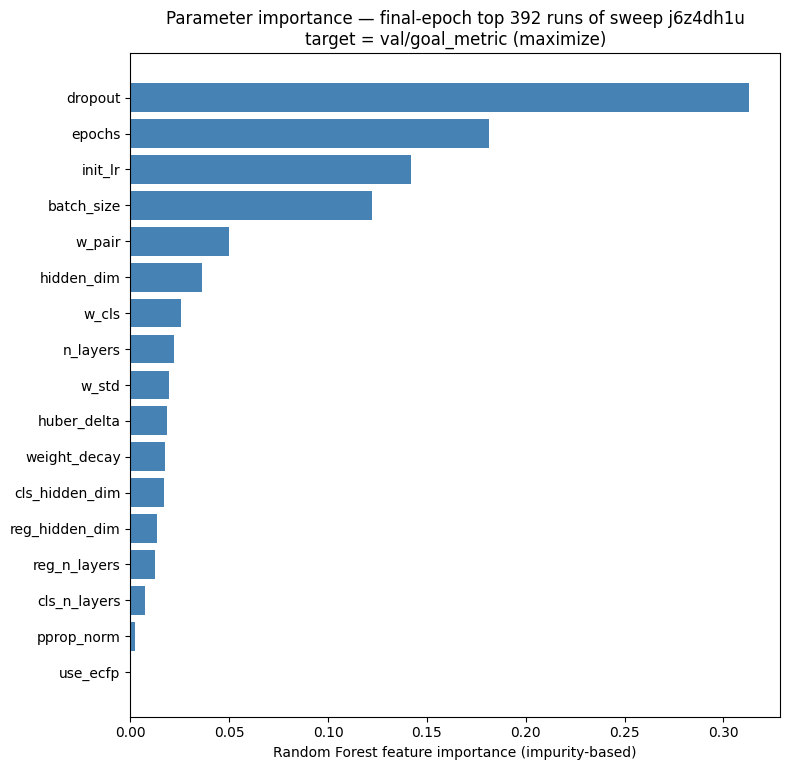

In [6]:
plot_importance(top_df, f"final-epoch top {n_top} runs of sweep {SWEEP_ID}")

## Where do the top-N runs sit in the full search space?

One scatter subplot per swept hyperparameter: x = value, y = goal metric. Axis scale and limits come from `sweeps/sweep.yaml` (log scale for `log_uniform_values` / `q_log_uniform_values` params, and the yaml's own min/max or `values` list rather than the observed data range) so you can see where the top-N runs sit within the *full* searched space, not just relative to each other.

In [7]:
top_df

,run_id,val_goal_metric,final_epoch,use_ecfp,pprop_norm,n_layers,hidden_dim,cls_n_layers,cls_hidden_dim,reg_n_layers,reg_hidden_dim,w_cls,w_pair,w_std,huber_delta,init_lr,weight_decay,dropout,batch_size,epochs
0,zfs9n2ln,1.448255,39,0,zscore,4,1740,3,468,3,804,0.441849,7.486448,0.791080,1.051318,0.000397,0.000013,0.221263,2191,40
1,9cw654d2,1.444898,49,0,zscore,3,1661,0,260,2,287,0.020478,1.420262,0.945641,0.309191,0.000767,0.010677,0.220781,1684,50
2,9qhv1smc,1.443871,81,0,zscore,2,1595,0,211,3,274,0.584274,3.380035,0.325454,1.816563,0.000261,0.083991,0.364344,1096,82
3,1jp9bm42,1.443716,97,0,zscore,3,982,0,158,3,759,0.089053,0.905054,0.074497,1.294198,0.000235,0.000004,0.269681,1338,98
4,ukgk5hxv,1.443198,53,0,none,4,1519,1,430,2,791,0.145274,2.441543,0.217421,0.250768,0.000419,0.000443,0.269231,1185,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,xlm3dyn8,1.344755,53,0,none,1,541,0,657,0,262,0.179058,0.731656,0.123758,0.670661,0.000089,0.000001,0.481324,3648,54
388,5dw3p57q,1.330036,20,0,none,3,774,3,443,3,372,0.120781,9.127290,0.433094,2.374554,0.000095,0.000038,0.443050,4842,21
389,6pimwrtw,1.321385,42,0,none,1,1231,2,144,0,632,0.009784,0.068547,0.256148,0.135453,0.000058,0.001895,0.367065,6454,43
390,k67rsmwv,1.320695,26,0,none,2,887,1,762,1,499,0.164972,0.041414,0.070788,2.663430,0.000050,0.000387,0.274352,7462,27


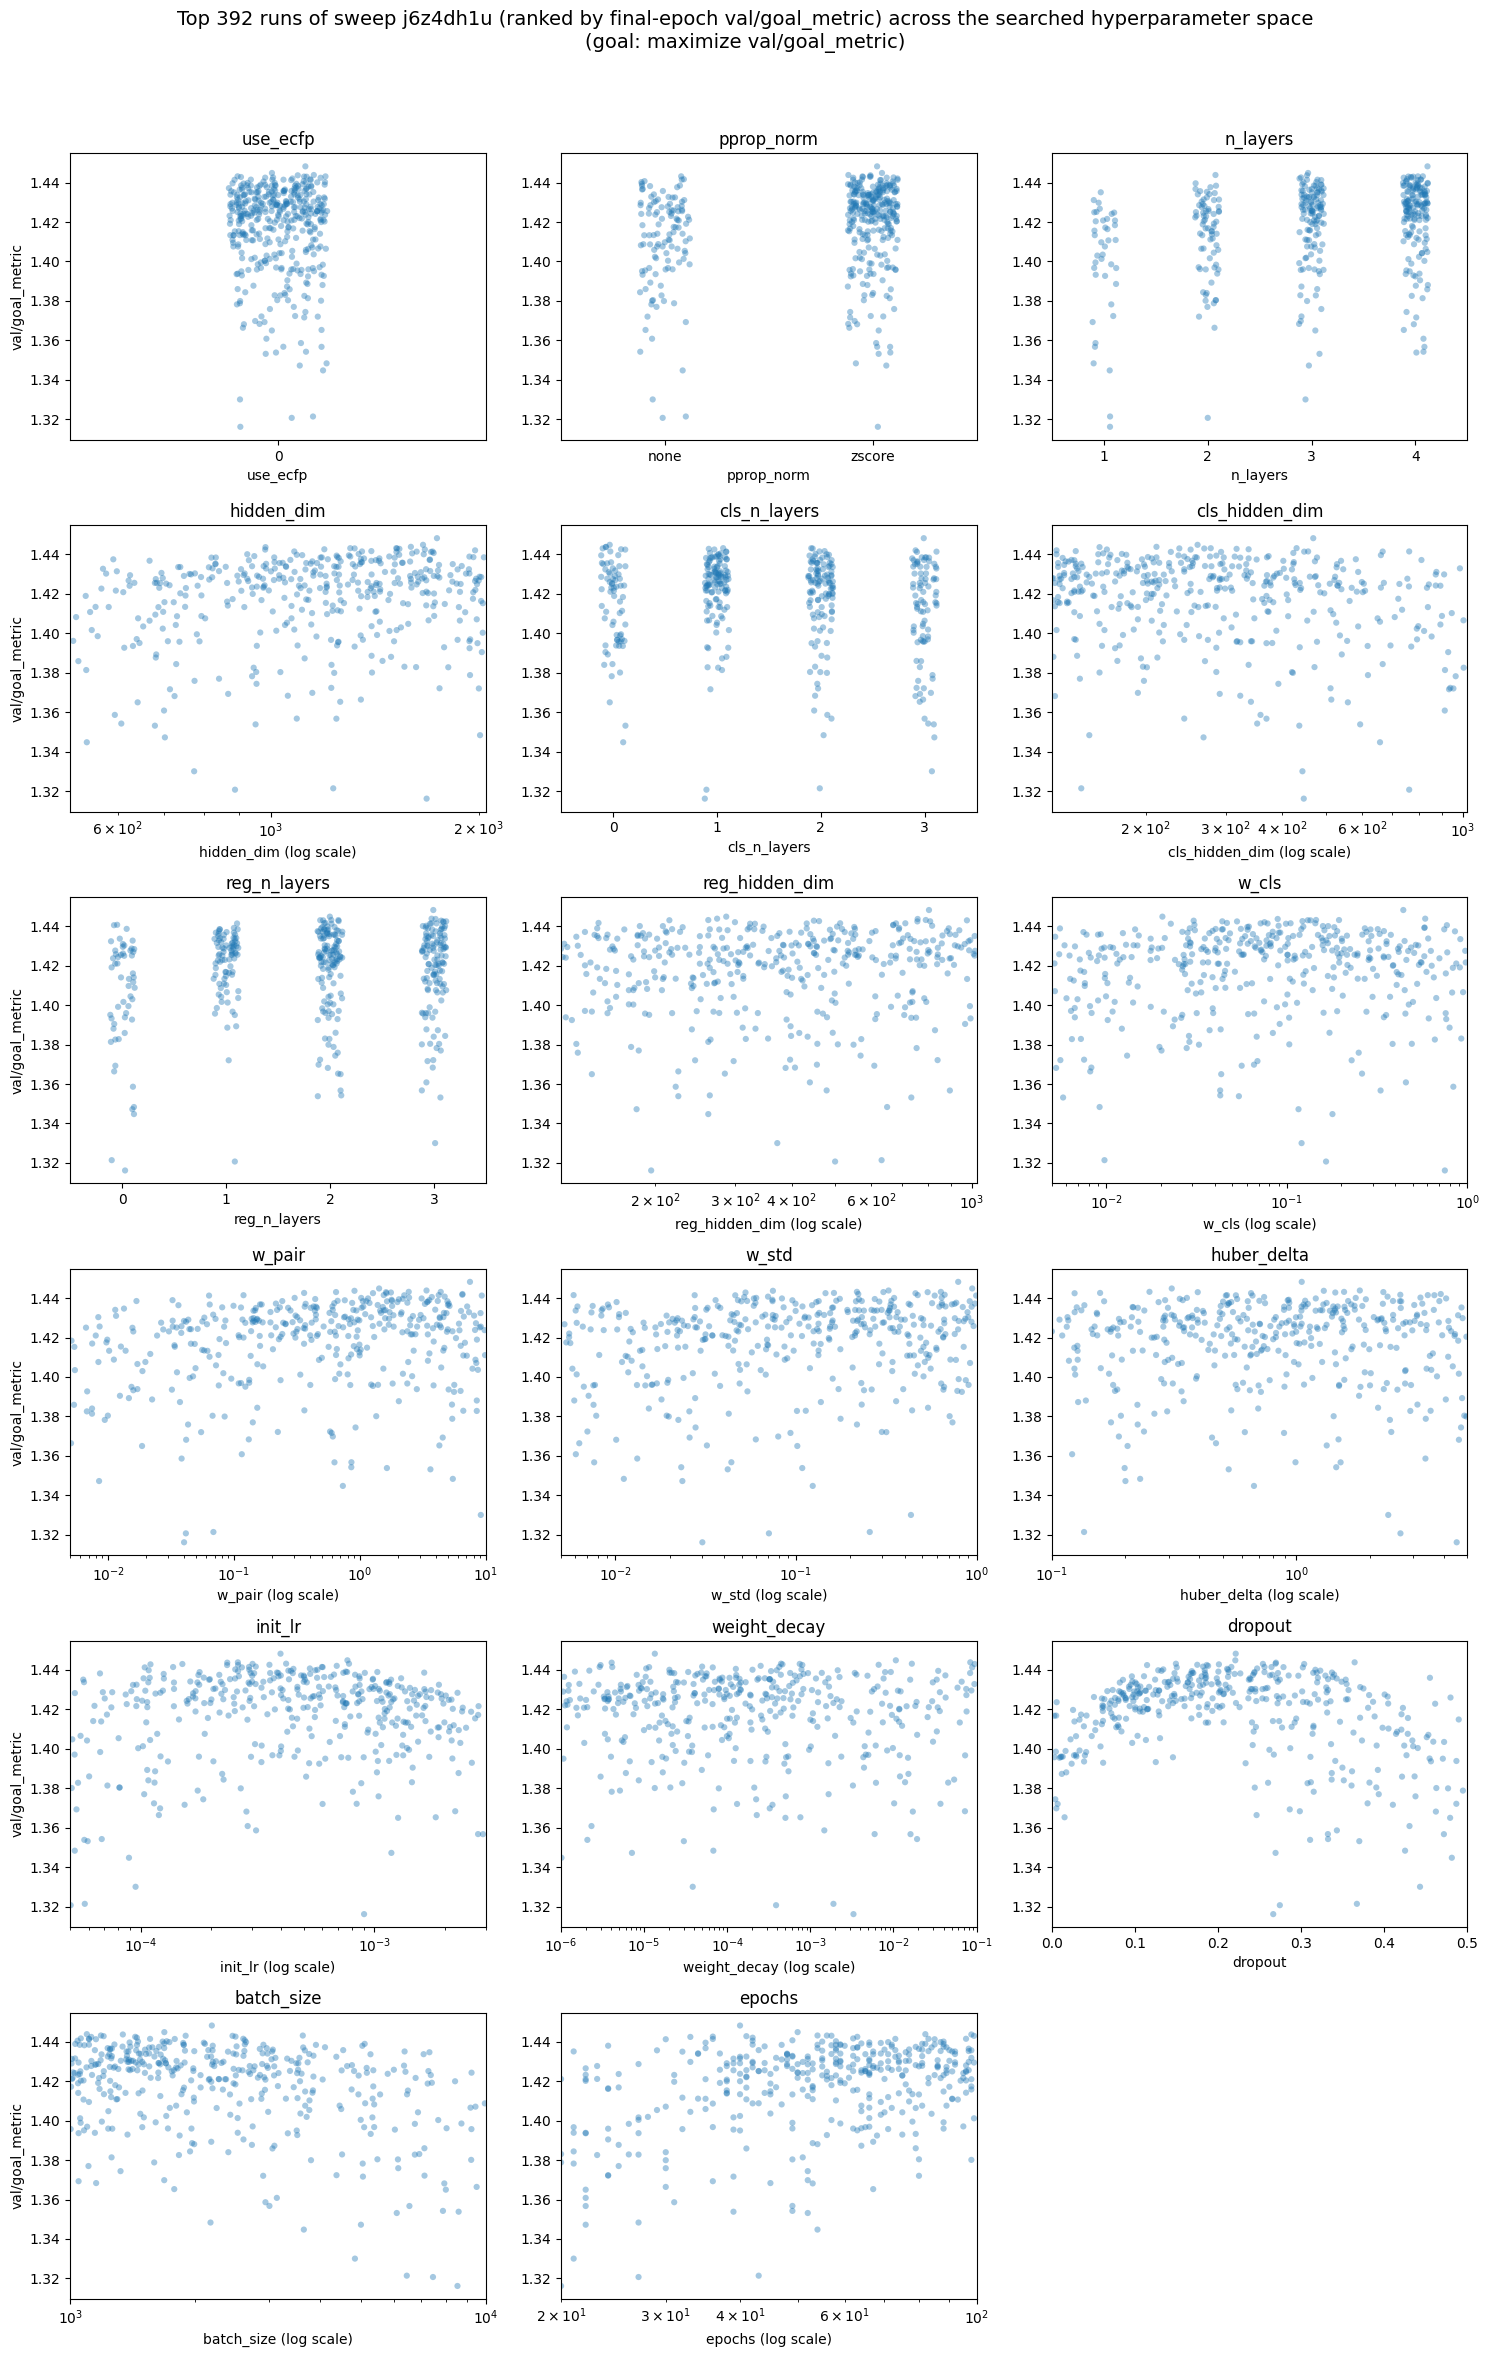

In [8]:
plot_scatter_grid(top_df, f"Top {n_top} runs of sweep {SWEEP_ID} (ranked by final-epoch {metric_name})")

Both figures above used the `SWEEP_ID` and `TOP_N` set in the second cell, ranked by **final-epoch** goal metric. Edit those and re-run the notebook to analyze a different sweep or a different top-N cutoff.

The next section repeats both figures ranked by **best-ever** goal metric instead.

## Best-ever goal_metric analysis (any epoch, not just final)

These runs train for a fixed number of epochs with no early stopping, so
`val/goal_metric` often peaks partway through training and then drifts back
down — the final-epoch value used above can miss runs that were actually very
good models mid-training.

Every run's full per-epoch history is stored **locally**, no wandb API needed:
`wandb/run-<timestamp>-<run_id>/run-<run_id>.wandb` is wandb's own local binary
log of every `wandb.log()` call the run made. This section scans that file per
run to find the best value `val/goal_metric` ever reached, and re-runs both
figures ranked by that instead of the final-epoch value.

In [12]:
def best_ever_metric(run_id, key, maximize):
    """Scan a run's local wandb history log and return (best_value, best_epoch)
    for `key` across all logged steps, or (None, None) if unavailable."""
    run_dirs = glob.glob(str(WANDB_DIR / f"run-*-{run_id}"))
    if not run_dirs:
        return None, None
    wandb_files = glob.glob(os.path.join(run_dirs[0], "*.wandb"))
    if not wandb_files:
        return None, None

    ds = DataStore()
    ds.open_for_scan(wandb_files[0])

    best_val, best_epoch = None, None
    while True:
        data = ds.scan_data()
        if data is None:
            break
        rec = pb.Record()
        rec.ParseFromString(data)
        if rec.WhichOneof("record_type") != "history":
            continue
        item_map = {}
        for item in rec.history.item:
            k = item.key if item.key else "/".join(item.nested_key)
            item_map[k] = item.value_json
        if key not in item_map:
            continue
        val = json.loads(item_map[key])
        if best_val is None or (val > best_val if maximize else val < best_val):
            best_val = val
            best_epoch = json.loads(item_map["epoch"]) if "epoch" in item_map else None
    return best_val, best_epoch

In [13]:
records = []
for _, row in df_all.iterrows():
    best_val, best_epoch = best_ever_metric(row["run_id"], metric_name, maximize=(goal == "maximize"))
    if best_val is None:
        continue
    rec = row.to_dict()
    rec[metric_col] = best_val
    rec["best_epoch"] = best_epoch
    records.append(rec)

df_best_all = pd.DataFrame.from_records(records)
n_missing_hist = len(df_all) - len(df_best_all)
print(f"Resolved best-ever {metric_name} for {len(df_best_all)}/{len(df_all)} runs "
      f"({n_missing_hist} missing local .wandb history)")

ascending_best = (goal == "minimize")
df_best_sorted = df_best_all.sort_values(metric_col, ascending=ascending_best).reset_index(drop=True)

n_available_best = len(df_best_sorted)
n_top_best = min(TOP_N, n_available_best)
if n_top_best < TOP_N:
    print(f"WARNING: requested TOP_N={TOP_N} but only {n_available_best} runs available; using {n_top_best}")

top_df_best = df_best_sorted.head(n_top_best).copy()

n_peaked_early = int((top_df_best["best_epoch"] != top_df_best["final_epoch"]).sum())
print(f"{n_peaked_early}/{n_top_best} of these top runs peaked at an epoch other than their final epoch")

print(f"SWEEP_ID={SWEEP_ID}  TOP_N={TOP_N} (n_used={n_top_best}, n_available={n_available_best})  "
      f"metric={metric_name} best-ever-across-training ({goal})")
top_df_best[["run_id", metric_col, "best_epoch", "final_epoch"]].head(10)

Resolved best-ever val/goal_metric for 1375/1375 runs (0 missing local .wandb history)
30/30 of these top runs peaked at an epoch other than their final epoch
SWEEP_ID=9okf022y  TOP_N=30 (n_used=30, n_available=1375)  metric=val/goal_metric best-ever-across-training (maximize)


,run_id,val_goal_metric,best_epoch,final_epoch
0,8gqznxfy,1.444549,51,59
1,iu8r7krf,1.444006,33,61
2,41364s3h,1.443031,31,38
3,p5te2g12,1.442793,43,74
4,x2e3fofl,1.442740,64,71
5,ntqfww5x,1.442635,56,63
6,w0exh6ic,1.441901,36,52
7,iuyqyysr,1.441736,34,52
8,lfrnaiz9,1.441414,46,65
9,n3iqw1ev,1.441333,46,61


In [14]:
top_df_best

,run_id,val_goal_metric,final_epoch,use_ecfp,pprop_norm,n_layers,hidden_dim,cls_n_layers,cls_hidden_dim,reg_n_layers,...,w_cls,w_pair,w_std,huber_delta,init_lr,weight_decay,dropout,batch_size,epochs,best_epoch
0,8gqznxfy,1.444549,59,0,none,2,1418,0,169,1,...,0.352008,0.080957,0.168350,1.604684,0.000530,0.002834,0.146092,2487,60,51
1,iu8r7krf,1.444006,61,0,none,2,1465,1,129,2,...,0.150331,0.073021,0.585294,1.060689,0.000243,0.065924,0.090575,2442,62,33
2,41364s3h,1.443031,38,0,none,2,1173,2,202,1,...,0.151603,0.045732,0.002568,1.669469,0.000659,0.000142,0.096616,2586,39,31
3,p5te2g12,1.442793,74,0,zscore,2,1459,2,196,1,...,0.134246,0.016496,0.003319,1.482913,0.000287,0.000010,0.213992,2722,75,43
4,x2e3fofl,1.442740,71,0,zscore,2,1412,0,222,3,...,0.173153,0.087815,0.008100,1.497881,0.000407,0.000027,0.219178,2774,72,64
5,ntqfww5x,1.442635,63,0,zscore,2,1550,0,281,2,...,0.124718,0.026893,0.232674,0.960802,0.000539,0.000642,0.180508,4169,64,56
6,w0exh6ic,1.441901,52,0,none,2,1460,1,321,2,...,0.189017,0.038376,0.002350,1.182214,0.000422,0.017568,0.102588,3338,53,36
7,iuyqyysr,1.441736,52,0,none,2,1481,0,191,2,...,0.138435,0.092510,0.002174,1.512224,0.000167,0.000023,0.099846,3375,53,34
8,lfrnaiz9,1.441414,65,0,zscore,2,1357,3,217,3,...,0.126630,0.081397,0.002553,0.185188,0.000497,0.048083,0.137232,2723,66,46
9,n3iqw1ev,1.441333,61,0,zscore,2,1471,1,266,2,...,0.145397,0.020647,0.027905,1.398733,0.000491,0.014322,0.227534,3047,62,46


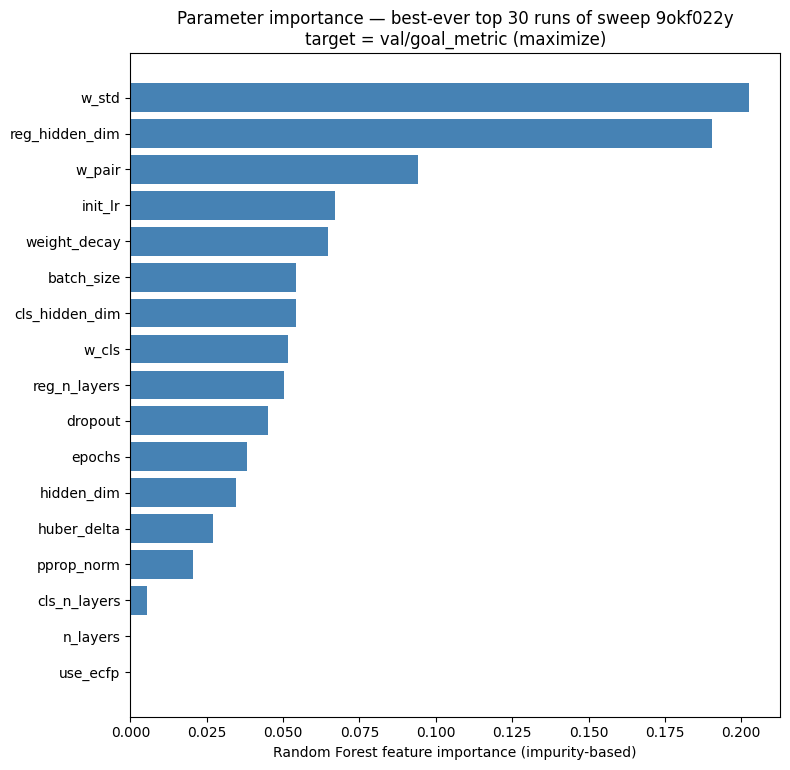

In [15]:
plot_importance(top_df_best, f"best-ever top {n_top_best} runs of sweep {SWEEP_ID}")

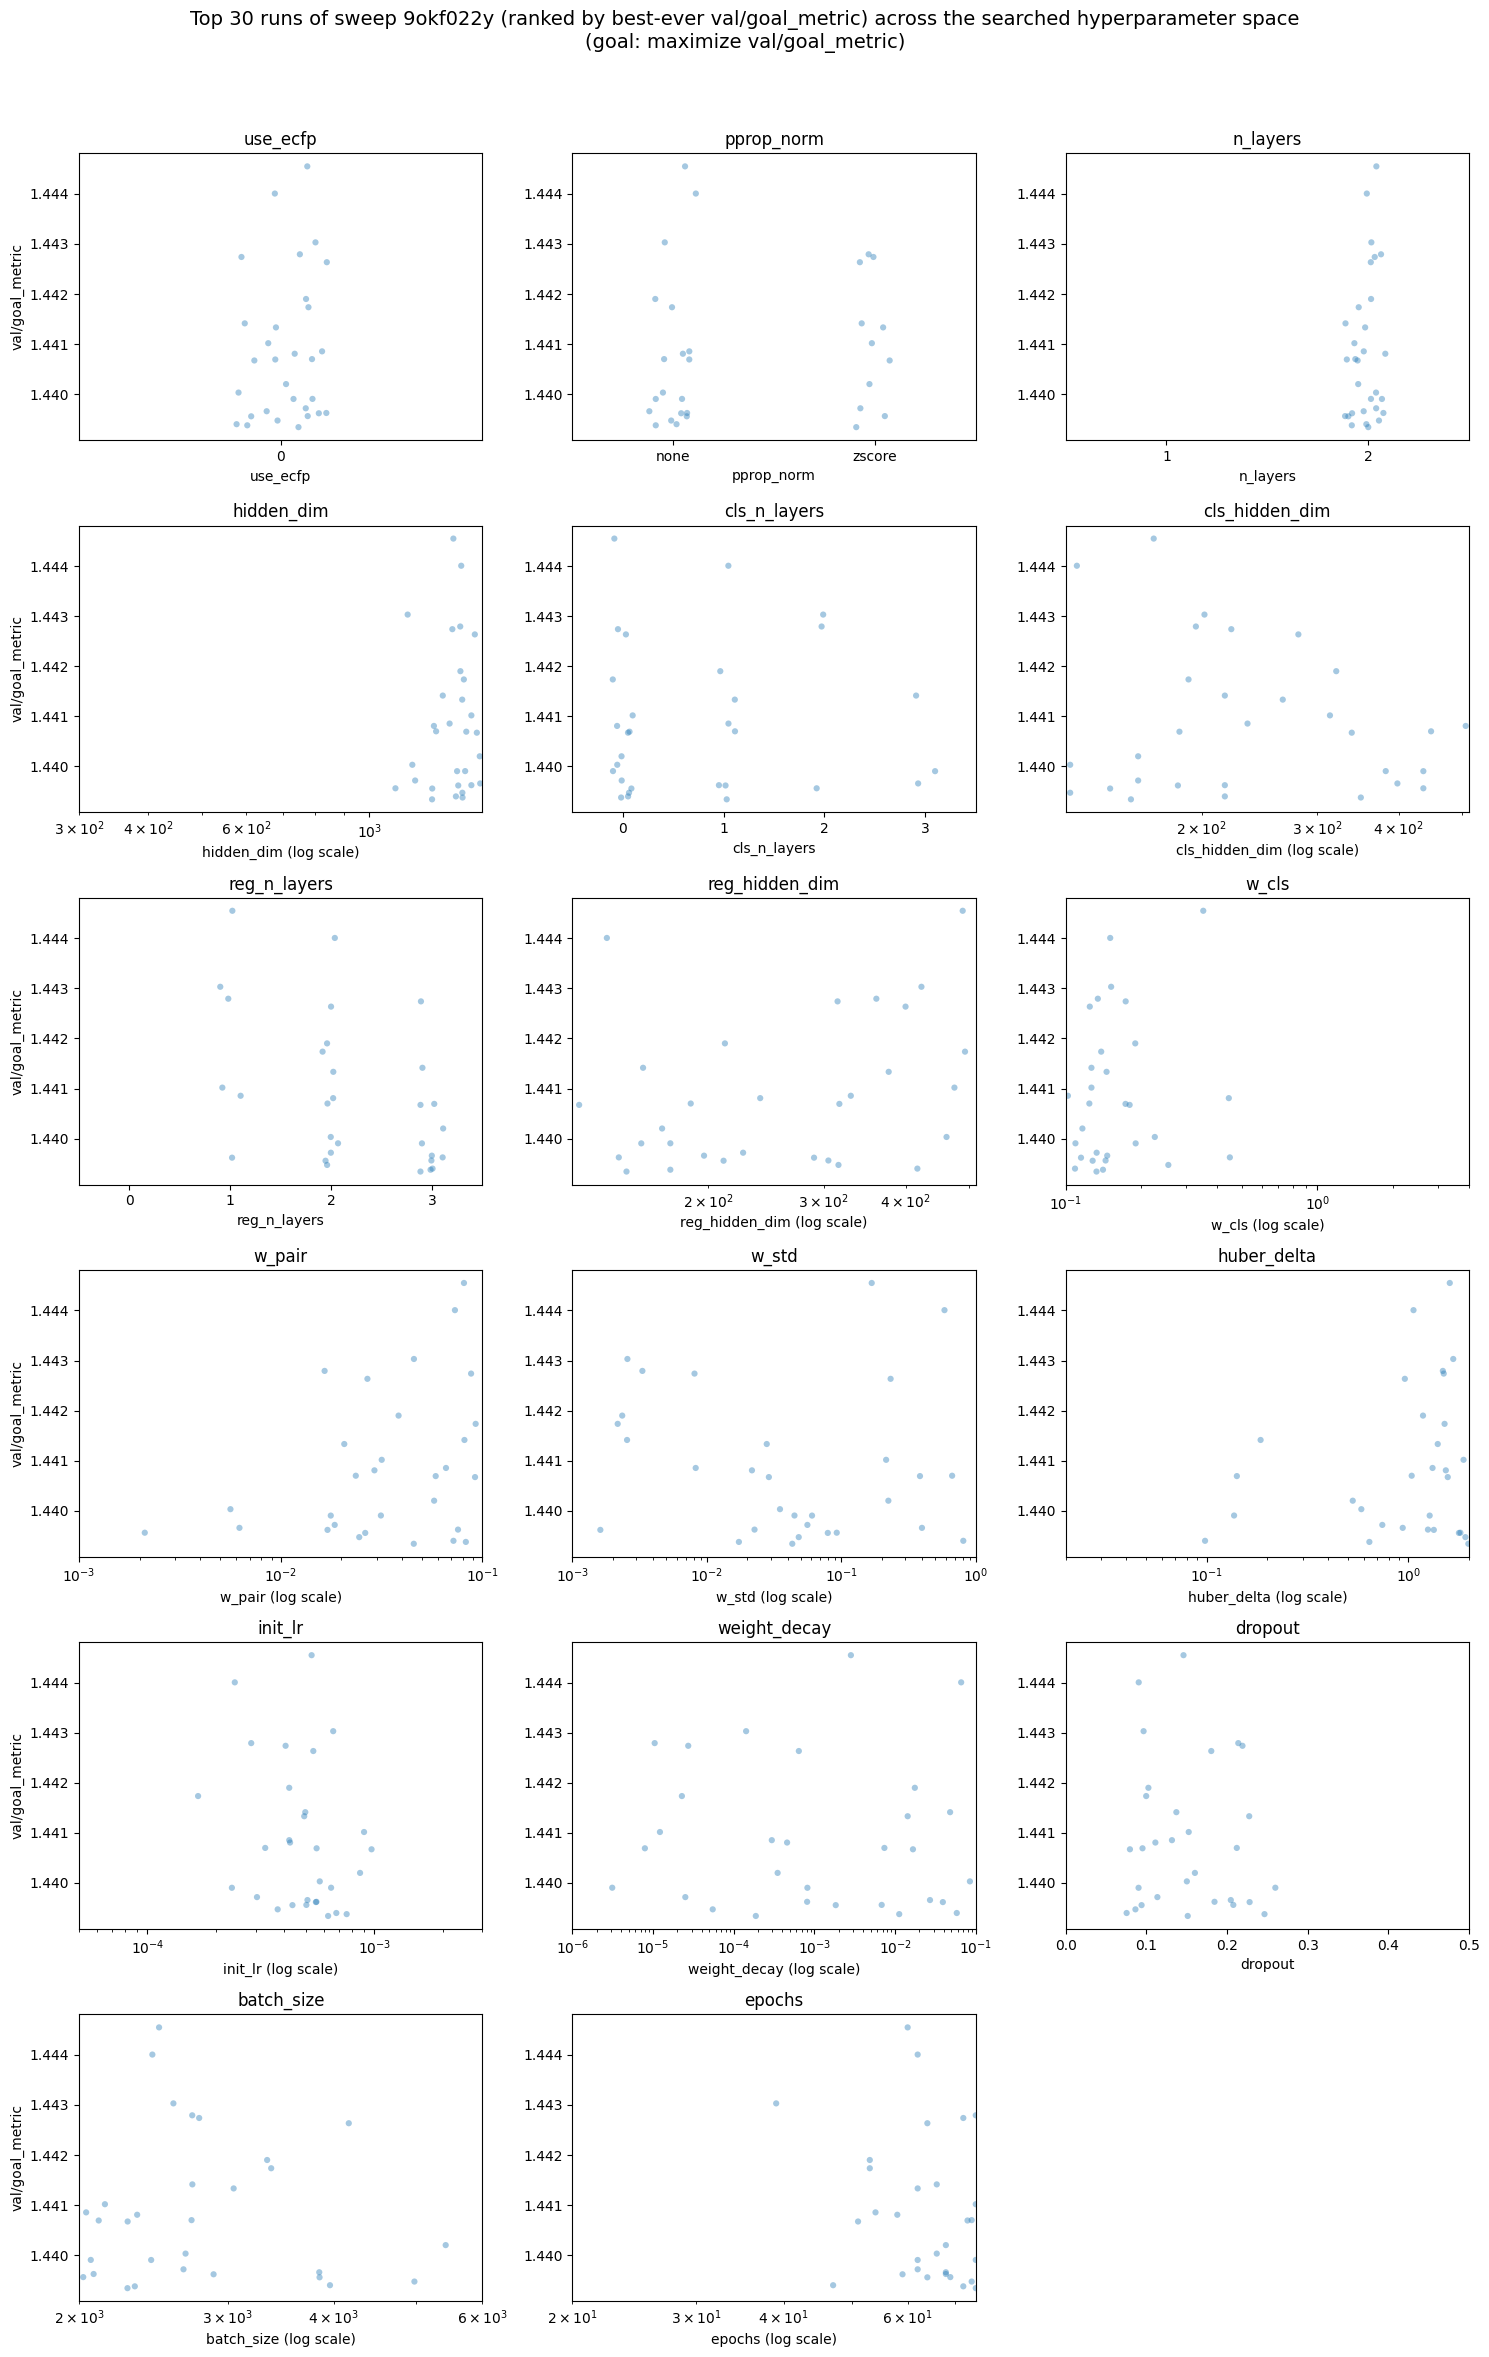

In [16]:
plot_scatter_grid(top_df_best, f"Top {n_top_best} runs of sweep {SWEEP_ID} (ranked by best-ever {metric_name})")

In [17]:
top_df_best

,run_id,val_goal_metric,final_epoch,use_ecfp,pprop_norm,n_layers,hidden_dim,cls_n_layers,cls_hidden_dim,reg_n_layers,...,w_cls,w_pair,w_std,huber_delta,init_lr,weight_decay,dropout,batch_size,epochs,best_epoch
0,8gqznxfy,1.444549,59,0,none,2,1418,0,169,1,...,0.352008,0.080957,0.168350,1.604684,0.000530,0.002834,0.146092,2487,60,51
1,iu8r7krf,1.444006,61,0,none,2,1465,1,129,2,...,0.150331,0.073021,0.585294,1.060689,0.000243,0.065924,0.090575,2442,62,33
2,41364s3h,1.443031,38,0,none,2,1173,2,202,1,...,0.151603,0.045732,0.002568,1.669469,0.000659,0.000142,0.096616,2586,39,31
3,p5te2g12,1.442793,74,0,zscore,2,1459,2,196,1,...,0.134246,0.016496,0.003319,1.482913,0.000287,0.000010,0.213992,2722,75,43
4,x2e3fofl,1.442740,71,0,zscore,2,1412,0,222,3,...,0.173153,0.087815,0.008100,1.497881,0.000407,0.000027,0.219178,2774,72,64
5,ntqfww5x,1.442635,63,0,zscore,2,1550,0,281,2,...,0.124718,0.026893,0.232674,0.960802,0.000539,0.000642,0.180508,4169,64,56
6,w0exh6ic,1.441901,52,0,none,2,1460,1,321,2,...,0.189017,0.038376,0.002350,1.182214,0.000422,0.017568,0.102588,3338,53,36
7,iuyqyysr,1.441736,52,0,none,2,1481,0,191,2,...,0.138435,0.092510,0.002174,1.512224,0.000167,0.000023,0.099846,3375,53,34
8,lfrnaiz9,1.441414,65,0,zscore,2,1357,3,217,3,...,0.126630,0.081397,0.002553,0.185188,0.000497,0.048083,0.137232,2723,66,46
9,n3iqw1ev,1.441333,61,0,zscore,2,1471,1,266,2,...,0.145397,0.020647,0.027905,1.398733,0.000491,0.014322,0.227534,3047,62,46


Both figures above used the same `SWEEP_ID` and `TOP_N`, but ranked runs by their best-ever `val/goal_metric` instead of their final-epoch value.